In [83]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

In [84]:
import kagglehub
path = kagglehub.dataset_download("kushsheth/face-vae")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'face-vae' dataset.
Path to dataset files: /kaggle/input/face-vae


In [85]:
file_dir=os.listdir(path);

In [86]:
source_folder = os.path.join(path, "img_align_celeba", "img_align_celeba")
destination_folder = "celeba_small/faces"
os.makedirs(destination_folder, exist_ok=True)
images = sorted(os.listdir(source_folder))[:5000]
for img in images:
    shutil.copy(
        os.path.join(source_folder, img),destination_folder
    )
print(destination_folder)

celeba_small/faces


In [87]:
#data preprocessing
image_Size=(64,64)
bath_size=32

In [88]:
datagen=ImageDataGenerator(rescale=1./255,validation_split=0.2)
train_generator=datagen.flow_from_directory("celeba_small",target_size=image_Size,class_mode="input",subset="training")

Found 4000 images belonging to 1 classes.


In [89]:
validation_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size=image_Size,
    batch_size=bath_size,
    class_mode="input",
    subset="validation",

)

Found 1000 images belonging to 1 classes.


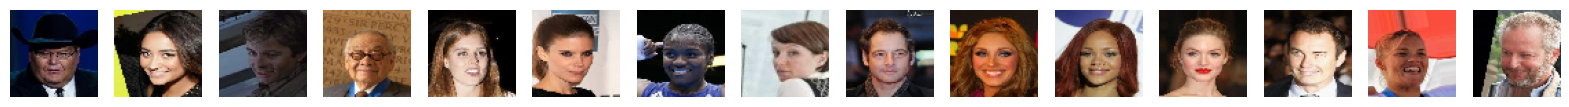

In [90]:
images,_=next(train_generator)
plt.figure(figsize=(20,19))
for i in range(15):
  plt.subplot(1,15,i+1)
  plt.imshow(images[i])
  plt.axis("off")
plt.show()

In [91]:
input_img=Input(shape=(64,64,3))
x=Conv2D(32,(3,3),activation='relu',padding='same')
(input_img)
input_img = Input(shape=(64, 64, 3))


In [100]:
# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
encoded = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)

decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

In [101]:
autoencoder = Model(inputs=input_img, outputs=decoded)

In [102]:
autoencoder.compile(optimizer="adam",loss="MSE")

In [103]:
autoencoder.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_18 (UpSampling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 64, 64, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,123 (82.51 KB)

 Trainable params: 21,123 (82.51 KB)

 Non-trainable params: 0 (0.00 B)

In [104]:
hist=autoencoder.fit(train_generator,validation_data=validation_generator,epochs=10)


Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 0.0210 - val_loss: 0.0061
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0047 - val_loss: 0.0039
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.0038 - val_loss: 0.0038
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0033 - val_loss: 0.0032
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0031 - val_loss: 0.0031
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0029 - val_loss: 0.0030
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0027 - val_loss: 0.0026
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0025 - val_loss: 0.0024
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.0024 - val_loss: 0.0023
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0024 - val_loss: 0.0022


In [112]:
loss=autoencoder.evaluate(validation_generator)
print(loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0022
0.002224547788500786


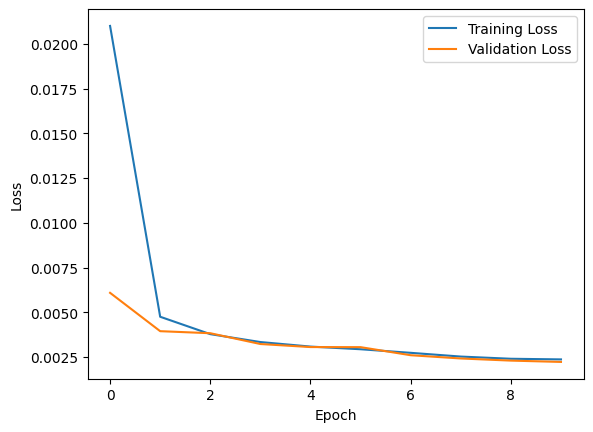

In [113]:
import matplotlib.pyplot as plt

plt.plot(hist.history['loss'], label='Training Loss')
plt.plot(hist.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()